# 05 Results Summary

Purpose: Aggregate saved Phase 2 results and regenerate final paper figures without rerunning inference.

Inputs: `results/phase2/evaluation_results.json`, `results/phase2/imbalance_results.json`, `results/phase2/continual_learning_results.json`.

Outputs: Regenerated figures in `figures/phase2/`, final summary table in notebook output, and `results/phase2/final_results_summary.csv`.

In [25]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../..").resolve()))

from src.phase2.config import get_phase2_config
from src.phase2.evaluation import load_results
from src.phase2.visualization import (
    plot_alpha_sensitivity,
    plot_confusion_matrices,
    plot_continual_learning_curve,
    plot_minority_f1_vs_imbalance,
    plot_phase2_vs_phase1,
    plot_scoring_comparison,
)

CONFIG = get_phase2_config()

REPO_ROOT = Path("../..").resolve()
EVAL_PATH = REPO_ROOT / "results" / "phase2" / "evaluation_results.json"
IMB_PATH = REPO_ROOT / "results" / "phase2" / "imbalance_results.json"
CONT_PATH = REPO_ROOT / "results" / "phase2" / "continual_learning_results.json"
FIG_DIR = REPO_ROOT / "figures" / "phase2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [26]:
evaluation_results = load_results(str(EVAL_PATH))
imbalance_results = load_results(str(IMB_PATH))
continual_results = load_results(str(CONT_PATH))

In [27]:
import csv

SUMMARY_CSV_PATH = REPO_ROOT / "results" / "phase2" / "final_results_summary.csv"
SUMMARY_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)

ratio_key = "100"
local_ttr = (
    imbalance_results.get("variants", {})
    .get("local_dnds", {})
    .get(ratio_key, {})
    .get("per_class_f1", {})
    .get("TTR", 0.0)
)
other_ttr = [
    metrics.get(ratio_key, {}).get("per_class_f1", {}).get("TTR", 0.0)
    for name, metrics in imbalance_results.get("variants", {}).items()
    if name != "local_dnds"
]
best_other_ttr = max(other_ttr) if other_ttr else 0.0
gain = local_ttr - best_other_ttr

best_variant_name = max(
    evaluation_results["variants"],
    key=lambda name: evaluation_results["variants"][name].get("macro_f1", 0.0),
)

rows = []
for name, metrics in evaluation_results["variants"].items():
    rows.append(
        {
            "variant": name,
            "accuracy": metrics.get("accuracy", 0.0),
            "macro_f1": metrics.get("macro_f1", 0.0),
            "weighted_f1": metrics.get("weighted_f1", 0.0),
            "ttr_f1": metrics.get("per_class_f1", {}).get("TTR", 0.0),
            "inference_time_ms": metrics.get(
                "inference_time_ms", metrics.get("latency_ms_per_sample", 0.0)
            ),
            "best_alpha": evaluation_results.get("best_alpha", "n/a"),
            "ttr_gain_100_to_best_other": gain,
            "is_best_rac": int(name == best_variant_name),
        }
    )

rows.append(
    {
        "variant": "phase1_traditional_baseline",
        "accuracy": 0.8216,
        "macro_f1": 0.8177,
        "weighted_f1": 0.8177,
        "ttr_f1": 0.8177,
        "inference_time_ms": 1.43,
        "best_alpha": evaluation_results.get("best_alpha", "n/a"),
        "ttr_gain_100_to_best_other": gain,
        "is_best_rac": 0,
    }
)

headers = [
    "variant",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "ttr_f1",
    "inference_time_ms",
    "best_alpha",
    "ttr_gain_100_to_best_other",
    "is_best_rac",
]

with SUMMARY_CSV_PATH.open("w", encoding="utf-8", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=headers)
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved consolidated final CSV: {SUMMARY_CSV_PATH}")

Saved consolidated final CSV: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\final_results_summary.csv


D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\src\phase2\visualization.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=variants, y=macro_f1, ax=ax, palette="viridis")
D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\src\phase2\visualization.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette=["#6c757d", "#2a9d8f"], ax=ax)


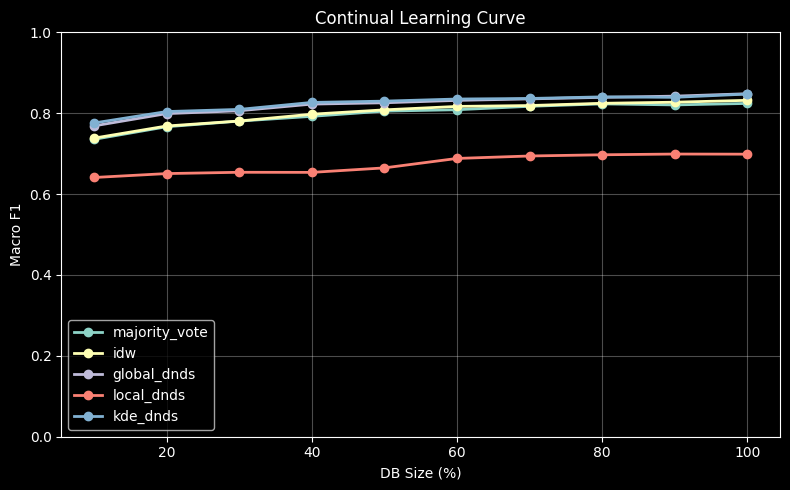

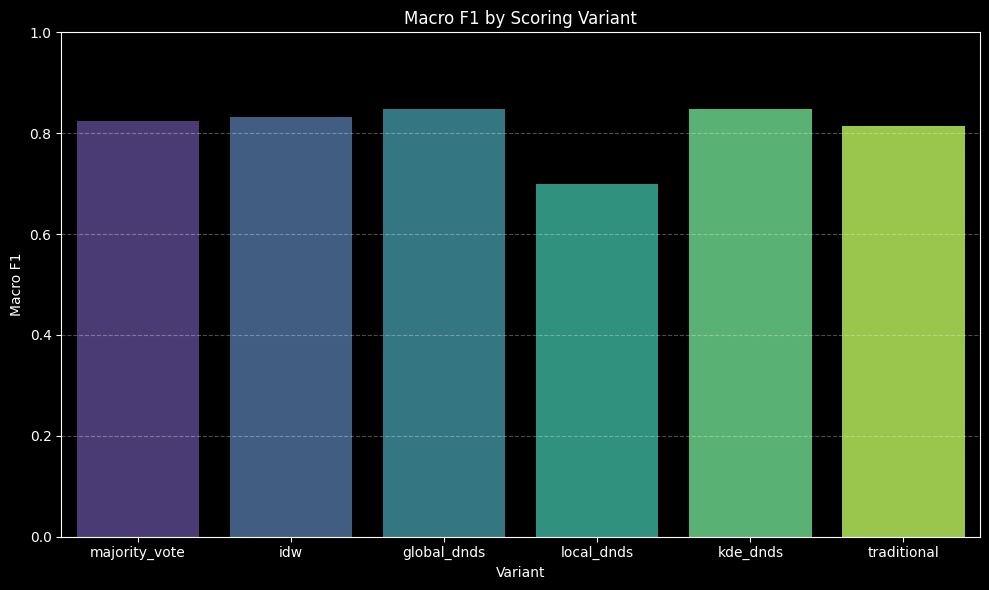

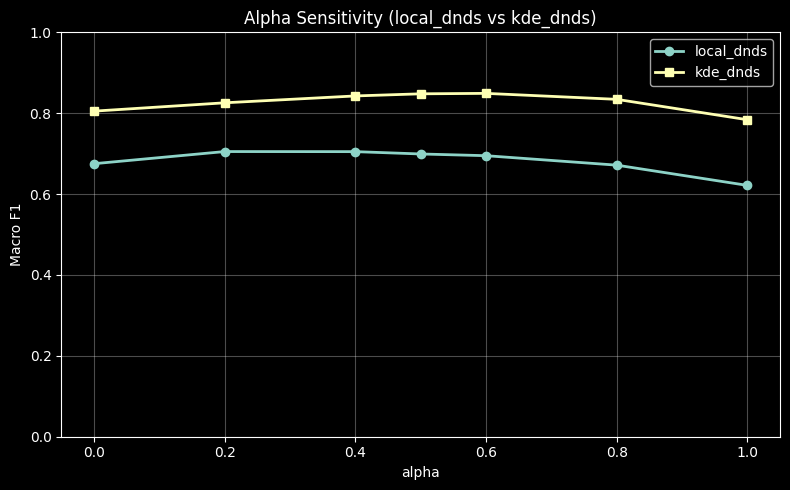

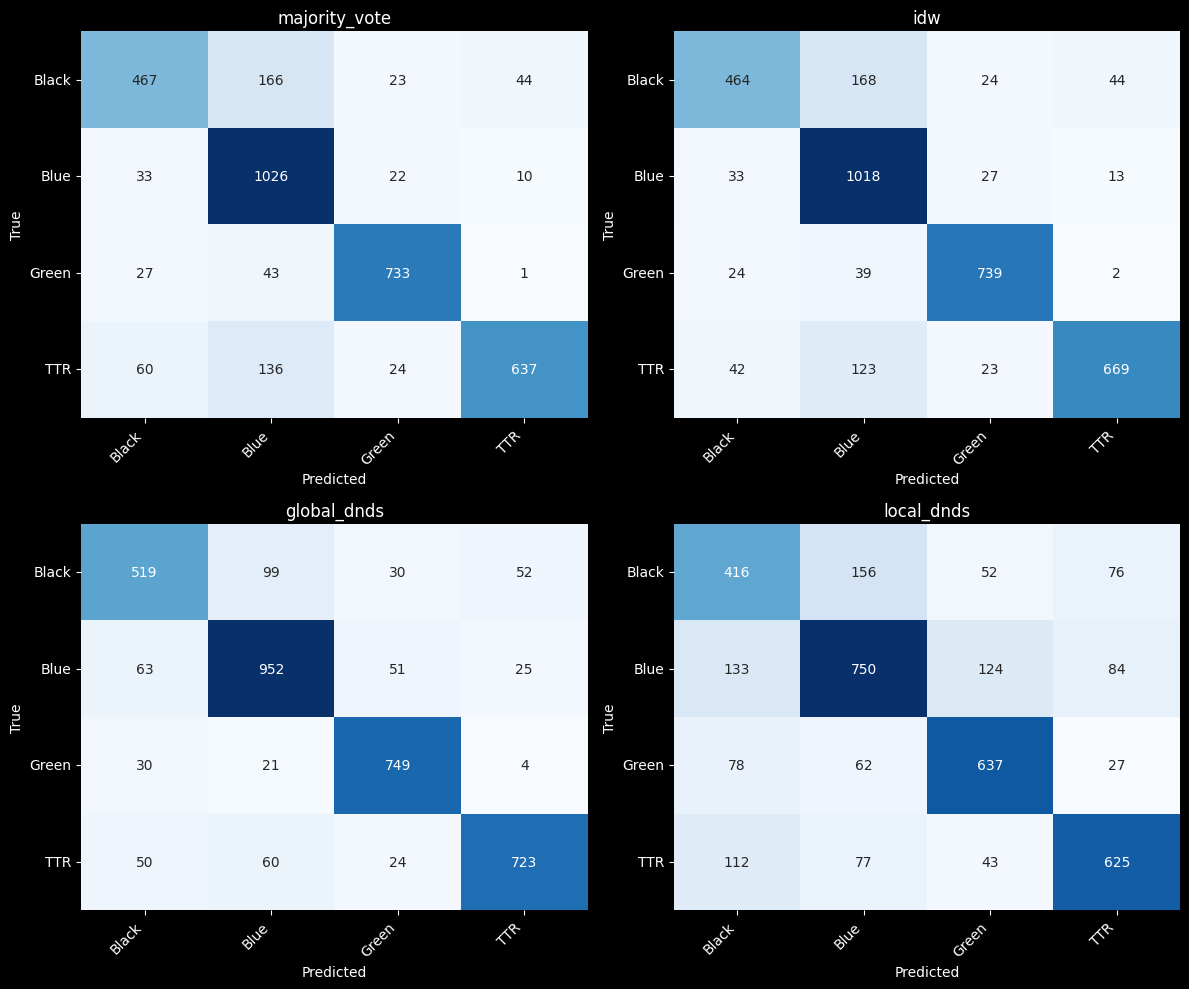

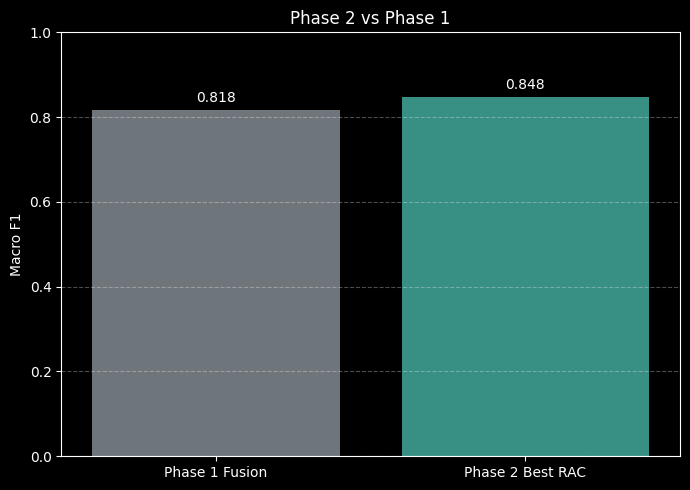

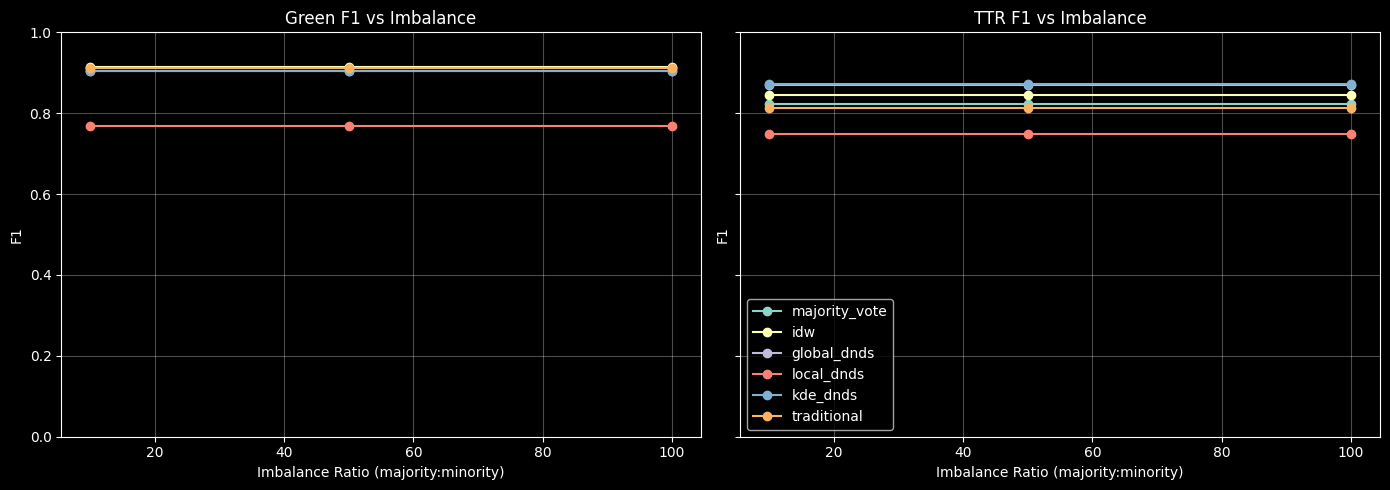

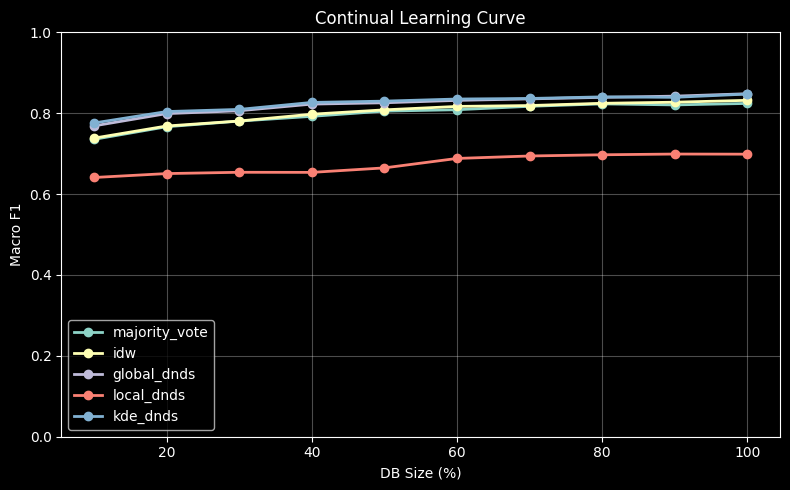

In [28]:
plot_scoring_comparison(evaluation_results, str(FIG_DIR / "scoring_comparison.png"))
plot_alpha_sensitivity(
    evaluation_results["alpha_sweep"], str(FIG_DIR / "alpha_sensitivity.png")
)
plot_confusion_matrices(
    evaluation_results,
    CONFIG["class_names"],
    str(FIG_DIR / "confusion_matrices_phase2.png"),
)
plot_phase2_vs_phase1(
    max(
        v.get("macro_f1", 0.0)
        for k, v in evaluation_results["variants"].items()
        if k != "traditional"
    ),
    0.8177,
    str(FIG_DIR / "phase2_vs_phase1.png"),
)
plot_minority_f1_vs_imbalance(
    imbalance_results, str(FIG_DIR / "minority_f1_vs_imbalance.png")
)
plot_continual_learning_curve(
    continual_results, str(FIG_DIR / "continual_learning_curve.png")
)

In [29]:
import pandas as pd

print("=" * 60)
print("PHASE 2 RAC EXPERIMENT - RESULTS SUMMARY")
print("=" * 60)
print("Variant              | Accuracy | Macro F1 | TTR F1 | Latency")
print("---------------------|----------|----------|--------|--------")
for name, metrics in evaluation_results["variants"].items():
    ttr_f1 = metrics.get("per_class_f1", {}).get("TTR", 0.0)
    latency = metrics.get(
        "inference_time_ms", metrics.get("latency_ms_per_sample", 0.0)
    )
    print(
        f"{name:<20} | {metrics['accuracy']*100:6.2f}% | {metrics['macro_f1']:.4f} | {ttr_f1:.4f} | {latency:.2f} ms"
    )

print(
    f"{'Phase 1 Traditional':<20} | {82.16:6.2f}% | {0.8177:.4f} | {0.8177:.4f} | {1.43:.2f} ms"
)
print("=" * 60)
print(f"Best alpha (local DNDS): {evaluation_results.get('best_alpha', 'n/a')}")

ratio_key = "100"
local_ttr = (
    imbalance_results.get("variants", {})
    .get("local_dnds", {})
    .get(ratio_key, {})
    .get("per_class_f1", {})
    .get("TTR", 0.0)
)
other_ttr = [
    metrics.get(ratio_key, {}).get("per_class_f1", {}).get("TTR", 0.0)
    for name, metrics in imbalance_results.get("variants", {}).items()
    if name != "local_dnds"
]
best_other_ttr = max(other_ttr) if other_ttr else 0.0
gain = local_ttr - best_other_ttr
print(f"Best imbalance correction gain on TTR F1 at 100:1 ratio: {gain:+.3f}")

phase1_fused_per_class = {
    "Black": 0.7141,
    "Blue": 0.8220,
    "Green": 0.9171,
    "TTR": 0.8177,
}

rac_variants = [
    name for name in evaluation_results["variants"].keys() if name != "traditional"
]
best_variant_name = max(
    rac_variants,
    key=lambda name: evaluation_results["variants"][name].get("macro_f1", 0.0),
)


def _build_wide_per_class_table(metric_key: str) -> pd.DataFrame:
    rows = []
    for cls in ["Black", "Blue", "Green", "TTR"]:
        row = {
            "Class": cls,
            "Phase 1 Fused": phase1_fused_per_class[cls],
        }
        for variant_name in rac_variants:
            row[variant_name] = (
                evaluation_results["variants"][variant_name]
                .get(metric_key, {})
                .get(cls, 0.0)
            )
        rows.append(row)
    table = pd.DataFrame(rows)
    value_cols = [c for c in table.columns if c != "Class"]
    table[value_cols] = table[value_cols].apply(
        lambda col: col.map(lambda x: f"{x:.4f}")
    )
    return table


print("")
print("Per-Class F1 Table (All RAC Variants)")
f1_table = _build_wide_per_class_table("per_class_f1")
print(f1_table)

print("")
print("Per-Class Precision Table (All RAC Variants)")
precision_table = _build_wide_per_class_table("per_class_precision")
print(precision_table)

print("")
print("Per-Class Recall Table (All RAC Variants)")
recall_table = _build_wide_per_class_table("per_class_recall")
print(recall_table)

print("")
print(f"Best RAC variant in this run (by Macro F1): {best_variant_name}")

PHASE 2 RAC EXPERIMENT - RESULTS SUMMARY
Variant              | Accuracy | Macro F1 | TTR F1 | Latency
---------------------|----------|----------|--------|--------
majority_vote        |  82.94% | 0.8236 | 0.8225 | 81.80 ms
idw                  |  83.72% | 0.8319 | 0.8442 | 86.70 ms
global_dnds          |  85.25% | 0.8482 | 0.8706 | 355.47 ms
local_dnds           |  70.34% | 0.6992 | 0.7490 | 83.50 ms
kde_dnds             |  85.23% | 0.8480 | 0.8716 | 632.27 ms
traditional          |  81.84% | 0.8137 | 0.8130 | 32.05 ms
Phase 1 Traditional  |  82.16% | 0.8177 | 0.8177 | 1.43 ms
Best alpha (local DNDS): n/a
Best imbalance correction gain on TTR F1 at 100:1 ratio: -0.123

Per-Class F1 Table (All RAC Variants)
   Class Phase 1 Fused majority_vote     idw global_dnds local_dnds kde_dnds
0  Black        0.7141        0.7257  0.7348      0.7621     0.5782   0.7618
1   Blue        0.8220        0.8335  0.8348      0.8565     0.7022   0.8543
2  Green        0.9171        0.9128  0.9140      0